<img src="https://247wallst.com/wp-content/uploads/2025/01/Stock-Market-Today.jpg"/>

## 📊 Introduction

Financial markets are inherently complex and driven by a combination of historical patterns, investor behavior, and external economic factors. Predicting stock prices is a challenging task due to their non-linear and volatile nature.

In recent years, deep learning models—especially Long Short-Term Memory (LSTM) networks—have gained popularity for time series forecasting. Unlike traditional models, LSTM networks are capable of capturing temporal dependencies and learning from sequential data.

In this study, we aim to build an LSTM-based model to predict future stock prices using historical data. The goal is not only to evaluate prediction accuracy but also to understand how well the model generalizes to unseen data.

In [1]:
# ================================
# 1. LIBRARIES
# ================================
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

## ⚙️ Methodology

### 📥 Data Collection
Historical stock price data was obtained using the Yahoo Finance API. The dataset includes daily closing prices over a multi-year period, which provides sufficient information for capturing long-term trends.

---

### ✂️ Train-Test Split
The dataset was divided into training and testing sets using a chronological split:

- Training set: 80% (past data)
- Testing set: 20% (future data)

Unlike traditional machine learning approaches, the data was not shuffled. This is crucial in time series analysis to prevent data leakage.

---

### ⚖️ Data Scaling
To improve model performance, the data was normalized using MinMaxScaler. Importantly, the scaler was fitted only on the training data and then applied to the test data. This ensures that the model does not gain access to future information during training.

---

### 🔁 Sequence Generation
LSTM models require sequential input data. Therefore, the dataset was transformed into sequences:

- Input: previous 100 days
- Output: next day price

This allows the model to learn temporal dependencies in the data.

---

### 🤖 Model Architecture
The model is based on a stacked LSTM architecture:

- Two LSTM layers with 100 units each
- Dropout layers to prevent overfitting
- A Dense output layer for price prediction

This structure enables the model to capture both short-term and long-term dependencies.

---

### ⚙️ Model Training
The model was trained using:

- Optimizer: Adam
- Loss function: Mean Squared Error (MSE)

EarlyStopping and ModelCheckpoint were used to improve training efficiency and prevent overfitting.

---

### 📊 Evaluation Metrics
The model performance was evaluated using:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² Score

These metrics provide a comprehensive understanding of prediction accuracy and model reliability.

In [2]:
# ================================
# 2. DATA
# ================================
data = yf.download("AAPL", period="5y")

dataset = data[['Close']].values

[*********************100%***********************]  1 of 1 completed


In [3]:
# ================================
# 3. TRAIN / TEST SPLIT (ÖNCE!)
# ================================
split = int(len(dataset) * 0.8)

train_data = dataset[:split]
test_data = dataset[split:]

In [4]:
# ================================
# 4. SCALE (SADECE TRAIN)
# ================================
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [5]:
# ================================
# 5. SEQUENCE FUNCTION
# ================================
def create_dataset(data, time_step=100):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_scaled)
X_test, y_test = create_dataset(test_scaled)

In [6]:
# ================================
# 6. RESHAPE (LSTM FORMAT)
# ================================
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [7]:
# ================================
# 7. MODEL
# ================================
model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(100))
model.add(Dropout(0.2))

model.add(Dense(1))

C:\Users\tamer\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# ================================
# 8. COMPILE
# ================================
model.compile(optimizer='adam',loss='mean_squared_error')

In [11]:
# ================================
# 9. CALLBACKS
# ================================
checkpoint = ModelCheckpoint(
    filepath='SM_LTSM_best.keras',
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [12]:
# ================================
# 10. TRAIN
# ================================
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - loss: 0.0014 - val_loss: 0.0040
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0014 - val_loss: 0.0036
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0016 - val_loss: 0.0036
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - loss: 0.0015 - val_loss: 0.0035
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0016 - val_loss: 0.0034
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 9/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0014 - val_loss: 0.0043
Epoch 10/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0015 - val_loss: 0.0055


In [13]:
# ================================
# 11. PREDICTION
# ================================
y_pred = model.predict(X_test)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step


In [14]:
# ================================
# 12. INVERSE SCALE
# ================================
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_real = scaler.inverse_transform(y_pred)

In [15]:
# ================================
# 13. METRICS
# ================================
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("\n===== MODEL PERFORMANCE =====")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R2  : {r2:.2f}")


===== MODEL PERFORMANCE =====
RMSE: 5.74
MAE : 4.58
R2  : 0.74


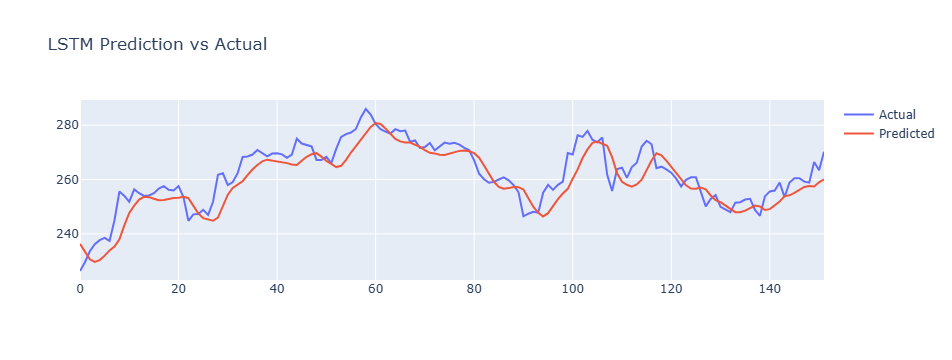

In [16]:
# ================================
# 14. GRAFİK
# ================================
fig = go.Figure()

fig.add_trace(go.Scatter(
    y=y_test_real.flatten(),
    name="Actual"
))

fig.add_trace(go.Scatter(
    y=y_pred_real.flatten(),
    name="Predicted"
))

fig.update_layout(title="LSTM Prediction vs Actual")
fig.show()


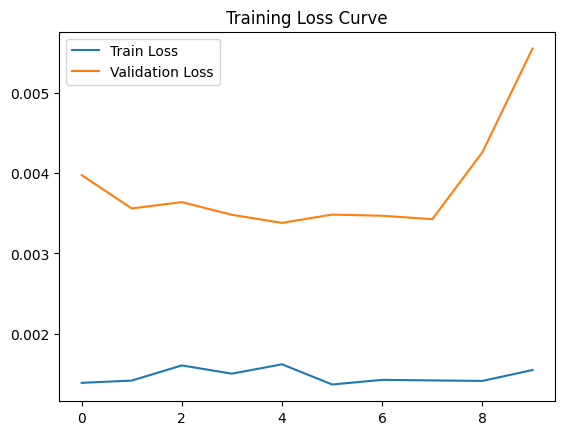

In [17]:
# ================================
# 15. LOSS GRAFİĞİ
# ================================
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train Loss','Validation Loss'])
plt.title("Training Loss Curve")
plt.show()

## 📈 Results and Discussion

The model's predictions were compared with actual stock prices using visualization techniques. The results show that the LSTM model is able to capture the general trend of the stock price, although some deviations occur during periods of high volatility.

The RMSE and MAE values indicate the average prediction error, while the R² score reflects how well the model explains the variance in the data.

It is important to note that financial markets are highly stochastic, and perfect prediction is not expected. However, the model demonstrates the ability to learn meaningful patterns from historical data.

Future improvements may include incorporating additional features such as trading volume, technical indicators, or combining the model with classification-based strategies for trading decisions.